In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mine.datasets import MultivariateNormalDataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_gpus = 1 if device=='cuda' else 0
print(device)

cuda


In [2]:
%load_ext autoreload
%autoreload 2
from mine.models.mine import MutualInformationEstimator
from pytorch_lightning import Trainer
import logging
logging.getLogger().setLevel(logging.ERROR)

dim = 1
N = 3000
lr = 1e-4
epochs = 200
batch_size = 500

steps = 15
rhos = np.linspace(-0.99, 0.99, steps)
loss_type = ['mine_biased']

results_dict = dict()

for loss in loss_type:
    results = []
    for rho in rhos:
        train_loader = torch.utils.data.DataLoader(
        MultivariateNormalDataset(N, dim, rho), batch_size=batch_size, shuffle=True)
        test_loader = torch.utils.data.DataLoader(
        MultivariateNormalDataset(N, dim, rho), batch_size=batch_size, shuffle=True)

        
        true_mi = train_loader.dataset.true_mi

        kwargs = {
            'lr': lr,
            'batch_size': batch_size,
            'train_loader': train_loader,
            'test_loader': test_loader,
            'alpha': 1.0
        }

        model = MutualInformationEstimator(
            dim, dim, loss=loss, **kwargs).to(device)
        
        trainer = Trainer(max_epochs=epochs, devices=num_gpus)
        trainer.fit(model)
        trainer.test()

        print("True_mi {}".format(true_mi))
        print("MINE {}".format(model.avg_test_mi))
        results.append((rho, model.avg_test_mi, true_mi))

    results = np.array(results)
    results_dict[loss] = results

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize the

Device: cuda
Epoch 199: 100%|██████████| 6/6 [00:00<00:00, 193.85it/s, v_num=67]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 6/6 [00:00<00:00, 172.56it/s, v_num=67]

d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\pytorch_lightning\trainer\connectors\checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_67\checkpoints\epoch=199-step=1200.ckpt


...

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 6/6 [00:00<00:00, 168.57it/s, v_num=81]

Restoring states from the checkpoint path at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_81\checkpoints\epoch=199-step=1200.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_81\checkpoints\epoch=199-step=1200.ckpt


Testing DataLoader 0: 100%|██████████| 6/6 [00:00<00:00, 260.83it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           -1.8127708435058594
         test_mi            1.8127708435058594
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
True_mi 1.9585182666778564
MINE 1.8127708435058594


C:\Users\admin\AppData\Local\Temp\ipykernel_6004\2433822403.py:11: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend(plots[0:2], labels = ['MINE', 'True MI'], loc='upper right')


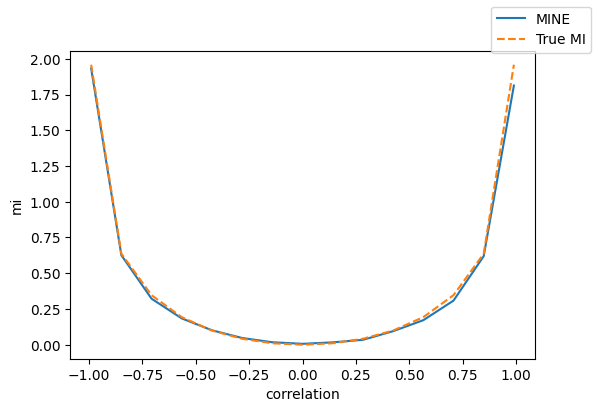

In [3]:
fig, axs = plt.subplots(1, len(loss_type), sharex = True, figsize = (6,4))
plots = []
for ix, loss in enumerate(loss_type):
    results = results_dict[loss]
    plots += axs.plot(results[:,0], results[:,1], label='MINE')
    plots += axs.plot(results[:,0], results[:,2], linestyle='--', label='True MI')
    axs.set_xlabel('correlation')
    axs.set_ylabel('mi')
    #axs.title.set_text(f"{loss} for {dim} dimensional inputs")
    
fig.legend(plots[0:2], labels = ['MINE', 'True MI'], loc='upper right')
fig.savefig('figures/mi_estimation.png')
    
    

In [4]:
## Function experiment
N = 3000
lr = 1e-4
batch_size = 256
epochs = 200

def f1(x): return x
def f2(x): return x**3
def f3(x): return torch.sin(x)

sigmas = torch.linspace(0, 0.9, 10)
fs = [f1, f2, f3]
dim = 2

res = []
for sigma in sigmas:
    for ix, f in enumerate(fs):
        print(f"Experiment: {ix + 1}, Sigma: {sigma}...")

        kwargs = {
            'N': N,
            'sigma': sigma,
            'f': f,
            'lr': lr,
            'batch_size': batch_size,
            'alpha': 0.1
        }

        model = MutualInformationEstimator(
            dim, dim, loss='mine_biased', **kwargs).to(device)
        trainer = Trainer(max_epochs=epochs, devices=num_gpus)
        trainer.fit(model)
        trainer.test()

        # Append result
        res.append([ix, sigma, model.avg_test_mi])


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type             | Params | Mode 
---------------------------------------------------------
0 | T           | CustomSequential | 10.7 K | train
1 | energy_loss | Mine             | 10.7 K | train
---------------------------------------------------------
10.7 K    Trainable params
0         Non-trainable params
10.7 K    Total params
0.043     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (12) is s

Experiment: 1, Sigma: 0.0...
Epoch 199: 100%|██████████| 12/12 [00:00<00:00, 307.73it/s, v_num=82]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 12/12 [00:00<00:00, 280.10it/s, v_num=82]

Restoring states from the checkpoint path at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_82\checkpoints\epoch=199-step=2400.ckpt


...

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 12/12 [00:00<00:00, 275.28it/s, v_num=111]

Restoring states from the checkpoint path at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_111\checkpoints\epoch=199-step=2400.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\lightning_logs\version_111\checkpoints\epoch=199-step=2400.ckpt


Testing DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 452.75it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          -0.29273098707199097
         test_mi            0.29273098707199097
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


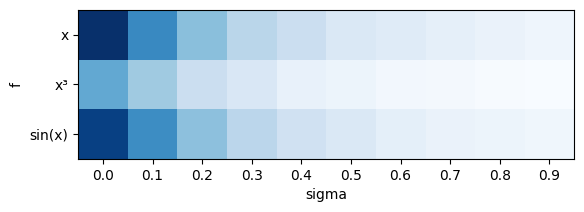

In [5]:
res = np.array(res)
Z = res[:, -1].reshape((len(sigmas), len(fs))).T
plt.figure()
plt.imshow(Z, cmap='Blues')
plt.yticks([0,1,2],['x', 'x³', 'sin(x)'])
plt.xticks(np.arange(10),sigmas.numpy().round(2))
plt.xlabel('sigma')
plt.ylabel('f')
plt.show()

## GANs

In [6]:
%load_ext autoreload
%autoreload 2
# GAN spiral experiment
from mine.models.gan import GAN
from mine.models.mine import T, Mine
from mine.datasets import load_dataloader
from pytorch_lightning import Trainer

from collections import defaultdict

datasets = ['gaussians']
loss = 'mine_biased'
num_samples = 4000
batch_size = 256
epochs = 600
lr = 1e-4
betas = [0.0, 1.0]
alpha = 0.1
#dataset = 'spiral'

results = defaultdict(dict)

for dataset in datasets:
    for beta in betas:
        train_loader = load_dataloader(dataset, batch_size, N=num_samples)
        img, label = next(iter(train_loader))

        output_dim = np.prod(img.shape[1:])
        input_dim = 100
        lr = lr
        beta = beta

        kwargs = {
            'lr': lr,
            'train_loader': train_loader,
            'beta': beta,
            'alpha': alpha,
            'use_conditional': True,
            'condition_on_labels': True
        }

        mi_model = T(output_dim, label.shape[-1]).to(device)
        mi_estimator = Mine(mi_model, loss=loss).to(device)

        model = GAN(input_dim, 
                    output_dim, 
                   generator_type = 'linear', 
                    discriminator_type = 'linear', 
                    mi_estimator=mi_estimator, 
                    conditional_dim=label.shape[-1], **kwargs).to(device)

        trainer = Trainer(max_epochs=epochs, devices=num_gpus)
        trainer.fit(model)

        generated_grid, conditional = model.generate_img_grid(num_samples)
        results[dataset][beta] = [generated_grid.cpu().data.numpy(), conditional.cpu().data.numpy()]
    
    


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | generator     | LinearGenerator     | 316 K  | train
1 | discriminator | LinearDiscriminator | 322 K  | train
2 | loss          | BCELoss             | 0      | train
3 | mi_estimator  | Mine                | 332 K  | train
--------------------------------------------------------------
971 K     Trainable params
0         Non-trainable params
971 K     Total params
3.885     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
d:\02-Infrequently-Accessed-Stor

Epoch 599: 100%|██████████| 16/16 [00:00<00:00, 90.82it/s, v_num=112, g_loss_step=0.814, d_loss_step=0.647, g_loss_epoch=0.868, d_loss_epoch=0.644] 

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 599: 100%|██████████| 16/16 [00:00<00:00, 77.10it/s, v_num=112, g_loss_step=0.814, d_loss_step=0.647, g_loss_epoch=0.868, d_loss_epoch=0.644]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | generator     | LinearGenerator     | 316 K  | train
1 | discriminator | LinearDiscriminator | 322 K  | train
2 | loss          | BCELoss             | 0      | train
3 | mi_estimator  | Mine                | 332 K  | train
--------------------------------------------------------------
971 K     Trainable params
0         Non-trainable params
971 K     Total params
3.885     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Epoch 599: 100%|██████████| 16/16 [00:00<00:00, 91.34it/s, v_num=113, g_loss_step=-1.69, d_loss_step=0.704, g_loss_epoch=-2.32, d_loss_epoch=0.662]     

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 599: 100%|██████████| 16/16 [00:00<00:00, 77.10it/s, v_num=113, g_loss_step=-1.69, d_loss_step=0.704, g_loss_epoch=-2.32, d_loss_epoch=0.662]


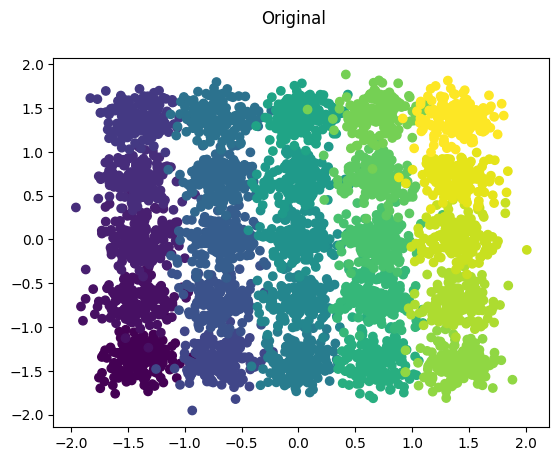

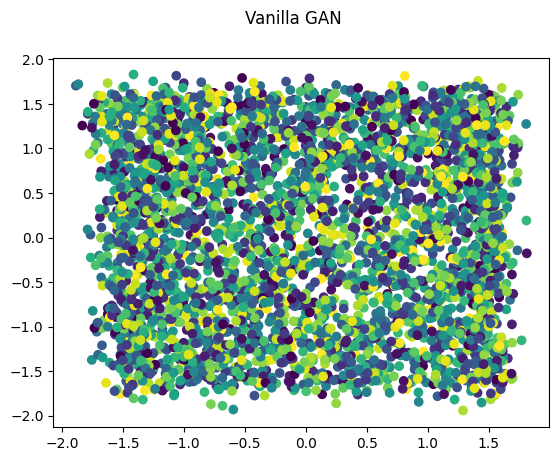

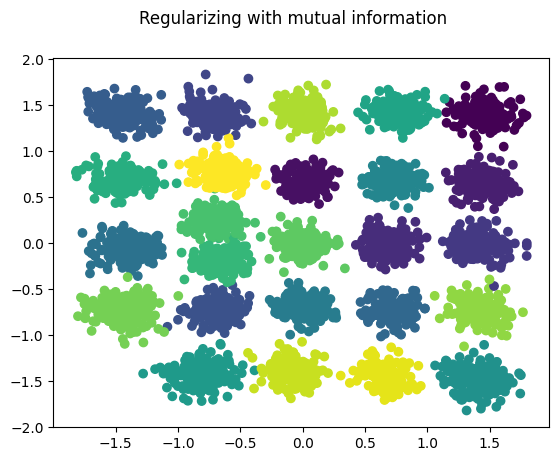

In [7]:
from mine.datasets import to_onehot

data = train_loader.dataset
x_np = data.x_np
labels = data.labels

plt.figure()
plt.scatter(x_np[:,0], x_np[:,1], c = labels)
plt.suptitle('Original')
plt.savefig('figures/25gaussians.png')

dataset = 'gaussians'
generated_grid, conditional = results[dataset][0.0]
model.plot_grid(generated_grid, conditional)
title = plt.suptitle('Vanilla GAN')
plt.savefig('figures/25gaussians_gan.png')

#plt.figure()
generated_grid, conditional = results[dataset][1.0]
model.plot_grid(generated_grid, conditional)
title = plt.suptitle('Regularizing with mutual information')
plt.savefig('figures/25gaussians_mine.png')

## IBNetwork on MNIST

In [8]:
from mine.models.information_bottleneck import IBNetwork, StatisticsNetwork
from mine.models.mine import Mine

batch_size = 512
epochs = 100
K = 256
beta = 1e-3
lr = 1e-3
x_dim = 28*28
z_dim = K


t = StatisticsNetwork(x_dim, z_dim, device=device).to(device)
mi_estimator = Mine(t, loss='mine', method='concat').to(device)
ibnetwork = IBNetwork(input_dim=28*28, K=K, output_dim=10,
                      mi_estimator=mi_estimator, lr=lr, beta=beta).to(device)

trainer = Trainer(max_epochs=epochs, devices=num_gpus)
trainer.fit(ibnetwork)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\torch\_compile.py:51: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | layers       | Sequential       | 2.4 M  | train
1 | decoder      | Linear           | 2.6 K  | train
2 | softplus     | Softplus         | 0      | train
3 | softmax      | Softmax          |

d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:484: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
d:\02-Infrequently-Accessed-Storage-30d\mine-pytorch\.pixi\envs\default\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 235/235 [00:07<00:00, 31.79it/s, v_num=114, val_loss=0.144, val_accuracy=0.983, val_error_rate=0.0169] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 235/235 [00:07<00:00, 31.15it/s, v_num=114, val_loss=0.144, val_accuracy=0.983, val_error_rate=0.0169]
